# OCT multi-class stratification 
Experiment with OCT as matching model!

# Models trained on unmatched original cohort. 

In [1]:
import sys
print(f"Python version: {sys.version}")
import json
import logging
import csv
import gzip
import re
import pandas as pd
import numpy as np
from functools import reduce
from pyspark.sql.types import StringType,DecimalType,DoubleType,IntegerType
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder
from pyspark.ml.feature import VectorAssembler, Bucketizer
import matplotlib.pyplot as plt
import pyspark.sql.functions as F
import pyspark.sql.types as T
from pyspark.sql import SparkSession,Row
from pyspark import SparkConf
import plotly.express as px
import plotly.graph_objects as go
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number, col
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# -----------------------------------------------------------------------------
# INITIALIZE LOGGING
# -----------------------------------------------------------------------------
f = '%(asctime)-15s %(levelname)-8s %(message)s'
logger = logging.getLogger(__name__)
logger.setLevel("DEBUG")
logging.basicConfig(format=f)


from IPython.core.magic import register_cell_magic

# -----------------------------------------------------------------------------
# start_spark
# -----------------------------------------------------------------------------
def start_spark(
    driver_memory="100g",
    storage_fraction=0.5,
    num_nodes=10,
):
    """Initialize spark

    Arguments:
        driver_memory: Maximum heap size for the Spark driver Java
            virtual machine.
        storage_fraction: Controls what portion of Spark's unified
            memory is reserved for storage (i.e., caching/persisting data
            and broadcast variables), as a fraction of the total
            execution + storage memory pool.
            If you cache/persist a lot of data, and you're evicting
            data too early, you might increase this value (e.g. 0.6 or 0.7).
            Conversely, if your job is shuffle-heavy and fails due to
            memory pressure, you might decrease it (e.g. 0.3).
        num_nodes: How many concurrent threads to use while running
            in "local mode" (i.e. in a single machine instead of a cluster).
            Use '*' to use all cores, or an integer > 0 for a specific
            number of threads.
    """

    conf = SparkConf().setAppName("My_Application")
    conf.set("spark.driver.memory", driver_memory)
    conf.set("spark.memory.storageFraction", str(storage_fraction))
    conf.setMaster(f"local[{num_nodes}]")

    spark = SparkSession.builder.config(conf=conf).getOrCreate()
    spark.sparkContext.setLogLevel('WARN')

    return spark


Python version: 3.11.0 (main, Jun 13 2025, 14:48:45) [Clang 16.0.0 (clang-1600.0.26.6)]


In [2]:

spark = start_spark(num_nodes=10)
#spark.stop()

  
@register_cell_magic
def spark_sql(line, cell):
    result = spark.sql(cell)
    result.show(n=1000)


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/11/22 10:02:47 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
df_2018 = spark.read.format("parquet").load( "0917_2017_18_with_2017_cost.parquet")
df_og = df_2018.toPandas()
df_og.shape,df_og.columns

25/11/22 10:02:49 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


((33542, 95),
 Index(['ENROLID', 'annual_cost_2017', 'highcost_gt_50000_2017',
        'highcost_gt_75000_2017', 'highcost_gt_100000_2017',
        'highcost_gt_200000_2017', 'highcost_gt_300000_2017',
        'highcost_gt_400000_2017', 'highcost_gt_500000_2017', 'INCOME_LEVEL',
        'annual_cost_2018_deflated', 'highcost_gt_50000', 'highcost_gt_75000',
        'highcost_gt_100000', 'highcost_gt_200000', 'highcost_gt_300000',
        'highcost_gt_400000', 'highcost_gt_500000', 'AGEGRP', 'SEX', 'REGION',
        'has_Hypertension', 'has_Type_2_Diabetes', 'has_Anemia',
        'has_Hyperlipidemia', 'has_Acute_Kidney_Failure',
        'has_Hyperparathyroidism', 'has_Kidney_Transplant',
        'has_Vitamin_D_Deficiency', 'has_Long-term_Drug_Therapy',
        'has_Hypothyroidism', 'has_Sleep_Apnea', 'stage_2017', 'util_2017',
        'Antihyperlipidemic Drugs, NEC (THRCLS_53)',
        'Cardiac, Beta Blockers (THRCLS_51)',
        'Cardiac, Calcium Channel (THRCLS_52)',
        'Psychot

# Feature groups, define high cost and train-test-split

In [4]:

import importlib
import model_pipeline
importlib.reload(model_pipeline)
import model_IAI
importlib.reload(model_IAI)

from model_IAI import train_oct_with_feature_names, finetune_oct


In [5]:
BIN_FLAG_COLUMNS = model_pipeline.get_bin_flag_columns(df_og) +['lab_monitoring_adherent','nephrology_consult_adherent','early_nephrology_referral']
STAGE_COLUMNS = [col for col in df_og.columns if "stage" in col.lower()]
#["stage_2017",'2017Q1_max_ckd_stage','2017Q2_max_ckd_stage', '2017Q3_max_ckd_stage','2017Q4_max_ckd_stage']
CAT_COLUMNS = df_og.select_dtypes(include=["object","category"]).columns.tolist()
TRUE_NUM_COLUMNS = model_pipeline.get_true_num_columns(df_og,CAT_COLUMNS)+[ 'util_2017', 'total_increasing_quarters_2017'
, 'total_lab_tests', 'ckd_visit_count', 'quarters_with_labs', 'nephrology_visit_count', 'days_to_nephrology','MEDIAN_INCOME']
COST_COLUMNS = [col for col in df_og.columns if 
            "cost" in col.lower() or 
             "quarterly" in col.lower()  or "increasing" in col.lower()
             ]
UTILIZATION_COLUMNS = [col for col in df_og.columns if "claims" not in col.lower() ] + ['util_2017']
print("categorical cols: ", CAT_COLUMNS)
print("stage cols: ", STAGE_COLUMNS)
print(COST_COLUMNS)
leftover_cols = [
    c for c in df_og.columns 
    if c not in CAT_COLUMNS and c not in TRUE_NUM_COLUMNS and c not in STAGE_COLUMNS and c not in BIN_FLAG_COLUMNS 
]

print(f"Number of leftover columns: {len(leftover_cols)}")
print(leftover_cols, df_og.shape)  # preview first 50

categorical cols:  ['ENROLID', 'INCOME_LEVEL', 'AGEGRP', 'SEX', 'REGION', 'cost_pattern_2017', 'cost_stability_2017', 'lab_monitoring_intensity']
stage cols:  ['stage_2017', '2017Q1_max_ckd_stage', '2017Q2_max_ckd_stage', '2017Q3_max_ckd_stage', '2017Q4_max_ckd_stage']
['annual_cost_2017', 'highcost_gt_50000_2017', 'highcost_gt_75000_2017', 'highcost_gt_100000_2017', 'highcost_gt_200000_2017', 'highcost_gt_300000_2017', 'highcost_gt_400000_2017', 'highcost_gt_500000_2017', 'annual_cost_2018_deflated', 'highcost_gt_50000', 'highcost_gt_75000', 'highcost_gt_100000', 'highcost_gt_200000', 'highcost_gt_300000', 'highcost_gt_400000', 'highcost_gt_500000', '2017Q1_ckd_cost', '2017Q1_direct_ckd_cost', '2017Q1_procedure_ckd_cost', '2017Q1_comorbidity_ckd_cost', '2017Q2_ckd_cost', '2017Q2_direct_ckd_cost', '2017Q2_procedure_ckd_cost', '2017Q2_comorbidity_ckd_cost', '2017Q3_ckd_cost', '2017Q3_direct_ckd_cost', '2017Q3_procedure_ckd_cost', '2017Q3_comorbidity_ckd_cost', '2017Q4_ckd_cost', '2017Q4

In [6]:
def make_cost_stratum_4class(df):
    # Default to low-cost (class 0)
    cost_stratum = pd.Series(0, index=df.index)
    # Moderate (class 1): 50k+ to 100k
    cost_stratum[(df['highcost_gt_50000'] == 1) & (df['highcost_gt_100000'] == 0)] = 1
    # Emergent high cost (class 2): 100k to 200k
    cost_stratum[(df['highcost_gt_100000'] == 1) & (df['highcost_gt_200000'] == 0)] = 2
    # High cost (class 2): 200k+
    cost_stratum[df['highcost_gt_200000'] == 1] = 3
    return cost_stratum
def make_cost_stratum_6class(df):
    # Default to low-cost (class 0)
    cost_stratum = pd.Series(0, index=df.index)
    # very low (class 1): 10k+ to 25k
    #cost_stratum[(df['annual_cost_2017'] >= 10000) & (df['annual_cost_2017']< 25000)] = 1
    # Mild (class 1): 25k+ to 50k
    #cost_stratum[(df['annual_cost_2017'] >= 25000) & (df['annual_cost_2017']< 50000)] = 2
    # Moderate (class 1): 50k+ to 100k
    cost_stratum[(df['highcost_gt_50000'] == 1) & (df['highcost_gt_100000'] == 0)] = 1
    # Emergent high cost (class 2): 100k to 200k
    cost_stratum[(df['highcost_gt_100000'] == 1) & (df['highcost_gt_200000'] == 0)] = 2
    # High cost (class 2): 200k+
    cost_stratum[(df['highcost_gt_200000'] == 1) & (df['highcost_gt_300000'] == 0)] = 3
    cost_stratum[df['highcost_gt_300000'] == 1] = 4
    
    return cost_stratum

# Add the new column to your data
df_og['cost_stratum_2018'] = make_cost_stratum_4class(df_og)
print(df_og["cost_stratum_2018"].value_counts(dropna=False))
target_col = 'highcost_gt_200000'

cost_stratum_2018
0    29401
1     1800
2     1398
3      943
Name: count, dtype: int64


In [7]:
cutoff_columns = [col for col in df_og.columns if col.startswith('highcost_gt_')]

feature_cols = [c for c in df_og.columns
              if c not in  (['annual_cost_2017','annual_cost_2018_deflated',"ENROLID", "cost_stratum_2018"] 
              + cutoff_columns)]    # keep only predictors excl. cost of 2018 and cutoff of 2017
numeric_cols = df_og[feature_cols + ["cost_stratum_2018"]].select_dtypes(include=["number"]).columns
corrs = df_og[numeric_cols].corr()["cost_stratum_2018"].abs().sort_values(ascending=False)
# Columns to drop
high_corr_cols = corrs[corrs > 0.5].index.tolist()
# Remove the target column itself, if present
high_corr_cols = [col for col in high_corr_cols if col != "cost_stratum_2018"]
# Final filtered feature set
feature_cols = [col for col in feature_cols if col not in high_corr_cols]
print("High corr features dropped from prediction columns: ",high_corr_cols)


# 2) split
train_ids, test_ids,train_pd,test_pd = model_pipeline.train_test_split_enrol(df_og,
    target_col = "cost_stratum_2018",test_size=0.3,verbose=False,random_state=123)
print(train_pd.shape,test_pd.shape)
print("Feature cols:", len(feature_cols))

val_ids, test_ids,val_pd,test_pd = model_pipeline.train_test_split_enrol(test_pd, target_col = "cost_stratum_2018",test_size=0.5,verbose=False)
X_test = test_pd[feature_cols]
y_test = test_pd[target_col]
X_val = val_pd[feature_cols]
y_val = val_pd[target_col]


High corr features dropped from prediction columns:  []
(23479, 96) (10063, 96)
Feature cols: 78


# TabPFN

In [24]:
# need small test set 
val_ids, test_ids,val_pd,test_pd = model_pipeline.train_test_split_enrol(test_pd, target_col = "cost_stratum_2018",test_size=0.5,verbose=False)
X_test = test_pd[feature_cols]
y_test = test_pd[target_col]
X_test.shape


(2516, 78)

In [39]:
undersampled_training_data =  pd.read_csv("w_sweep_results_allmajority/undersampled_w_0.00.csv")
undersampled_training_data["cost_stratum_2018"].value_counts()

_,_,full_pd,imb_train_pd = model_pipeline.train_test_split_enrol(df_og, target_col = "cost_stratum_2018",test_size=0.2,verbose=False)
imb_train_pd["cost_stratum_2018"].value_counts()
imb_train_pd["cost_stratum_2018"].value_counts(normalize=False)


cost_stratum_2018
0    5881
1     360
2     280
3     188
Name: count, dtype: int64

In [8]:
import torch

print("==============================================")
print(" PyTorch CUDA Diagnostics")
print("==============================================")

print(f"torch.version.cuda:        {torch.version.cuda}")
print(f"torch.cuda.is_available(): {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"torch.cuda.device_count(): {torch.cuda.device_count()}")
    for i in range(torch.cuda.device_count()):
        print(f"GPU {i}: {torch.cuda.get_device_name(i)}")
else:
    print("No GPU detected by PyTorch. Running on CPU only.")

print("==============================================\n")


 PyTorch CUDA Diagnostics
torch.version.cuda:        None
torch.cuda.is_available(): False
No GPU detected by PyTorch. Running on CPU only.



In [ ]:
import os, pickle

import model_IAI
importlib.reload(model_IAI)
from model_IAI import evaluate_binary_oct, finetune_oct
import balancing_functions.bilevel_sampler
importlib.reload(balancing_functions.bilevel_sampler)
from balancing_functions.bilevel_sampler import BilevelResampler

minbuckets_M2 = [50, 100, 120, 150]
cps_M2 = [0.00001, 5e-5, 0.0001, 5e-3]
depths_M2 = [5, 7]

# -----------------------
# Build matcher once
# -----------------------
matcher = BilevelResampler(
    matching_method="ortools",
    random_state=42,
    binary_group=target_col,
    uid_col="ENROLID",
)

# Separate majority/minority
maj = train_pd[train_pd[target_col] == 0].copy()
# OPTIONAL: restrict to stratum 0
# maj = maj[maj["cost_stratum_2018"] == 0]

minr = train_pd[train_pd[target_col] == 1].copy()


results_dir = "./w_sweep_results_pushpull_ratio1"
os.makedirs(results_dir, exist_ok=True)
metrics_master_path = f"{results_dir}/metrics_tabpfn.csv"

all_metrics = []

w_values = np.linspace(0.0, 1.0, 11)

for w in w_values:
    print("\n====================================")
    print(f"  Loading unified MILP sampling w={w:.2f}")
    print("====================================\n")
    # Save undersampled dataset
    save_path = f"{results_dir}/undersampled_w_{w:.2f}.csv"
    undersampled_training_data = pd.read_csv(save_path)
    print("\n====================================")
    print(f"ICL of TabPFN for w={w:.2f}")
    print("====================================\n")
    

    print("\n====================================")
    print(f"Inference of TabPFN for w={w:.2f}")
    print("====================================\n")
    
    # Evaluate
    metrics = evaluate_binary_oct(
        balanced_model,
        X_test,
        y_test,
        preprocessor,
        feature_names
    )

    row = metrics.copy()
    row["w"] = w

    # Append to master table
    pd.DataFrame([row]).to_csv(metrics_master_path, mode='a',
                               header=not os.path.exists(metrics_master_path),
                               index=False)

    all_metrics.append(row)


In [41]:
# Fine-tune TabPFN on undersampled_training_data and inference on test_pd
import torch
try:
    from tabpfn import TabPFNClassifier
    from sklearn.metrics import roc_auc_score, precision_recall_curve, average_precision_score, confusion_matrix, classification_report
    TABPFN_AVAILABLE = True
    import os
    os.environ["TABPFN_ALLOW_CPU_LARGE_DATASET"] = "1"

except ImportError:
    TABPFN_AVAILABLE = False

    print("Warning: TabPFN not installed. Install with: pip install tabpfn")
    # Hard predictions (use same batching logic)
def tabpfn_predict_classes_in_batches(model, X, batch_size=256):
    preds = []
    n = len(X)
    for start in range(0, n, batch_size):
        end = start + batch_size
        batch = X[start:end]
        with torch.inference_mode():
            p = model.predict(batch)
        preds.append(p)
    return np.concatenate(preds)

def tabpfn_predict_proba_in_batches(model, X, batch_size=256):
    preds = []
    n = len(X)
    for start in range(0, n, batch_size):
        end = start + batch_size
        batch = X[start:end]
        with torch.inference_mode():
            p = model.predict_proba(batch)
        preds.append(p)
    return np.vstack(preds)


if TABPFN_AVAILABLE:
    print("=" * 60)
    print("TabPFN Fine-tuning and Inference")
    print("=" * 60)
    
    # Prepare training data
    X_train_tabpfn = imb_train_pd[feature_cols].copy() 
    y_train_tabpfn = imb_train_pd[target_col].copy()
    
    #X_train_tabpfn = undersampled_training_data[feature_cols].copy()
    #y_train_tabpfn = undersampled_training_data[target_col].copy()
    
    # Prepare test data
    X_test_tabpfn = test_pd[feature_cols].copy()
    y_test_tabpfn = test_pd[target_col].copy()
    
    print(f"\nTraining data shape: {X_train_tabpfn.shape}")
    print(f"Test data shape: {X_test_tabpfn.shape}")
    print(f"Training target distribution:\n{y_train_tabpfn.value_counts()}")
    print(f"Test target distribution:\n{y_test_tabpfn.value_counts()}")
    
    # Use the same preprocessor as other models for consistency
    from model_pipeline import get_preprocessor
    
    preprocessor_tabpfn = get_preprocessor(
        X_train_tabpfn,
        categorical_cols=CAT_COLUMNS,
        numeric_cols=TRUE_NUM_COLUMNS,
        verbose=True
    )
    
    # Transform training and test data
    print("\nPreprocessing data...")
    X_train_transformed = preprocessor_tabpfn.fit_transform(X_train_tabpfn)
    X_test_transformed = preprocessor_tabpfn.transform(X_test_tabpfn)
    
    print(f"Transformed training shape: {X_train_transformed.shape}")
    print(f"Transformed test shape: {X_test_transformed.shape}")
    
    # Initialize TabPFN
    # TabPFN works best with smaller datasets, so we'll use it directly
    # For fine-tuning, we use the fit method
    print("\n" + "=" * 60)
    print("Initializing and fine-tuning TabPFN...")
    print("=" * 60)
 
    tabpfn_model = TabPFNClassifier(
        device='cpu',ignore_pretraining_limits=True
    )
    
    # Fine-tune TabPFN on the undersampled training data
    print("\nFine-tuning TabPFN on undersampled training data...")

    tabpfn_model.fit(X_train_transformed, y_train_tabpfn)
    
    print("Fine-tuning complete!")
    
    # Make predictions on test set
    print("\n" + "=" * 60)
    print("Running inference on test_pd...")
    print("=" * 60)
    
    print("Running batch-wise inference...")

    # Probabilities
    y_pred_proba = tabpfn_predict_proba_in_batches(
    tabpfn_model,
    X_test_transformed,
    batch_size=256,)

    # Extract positive class probability
    y_pred_proba_positive = (
        y_pred_proba[:, 1] if y_pred_proba.shape[1] > 1 else y_pred_proba[:, 0]
    )

    y_pred = tabpfn_predict_classes_in_batches(
        tabpfn_model,
        X_test_transformed,
        batch_size=256,
    )


    # Calculate metrics
    print("\n" + "=" * 60)
    print("Evaluation Metrics")
    print("=" * 60)
    
    auc = roc_auc_score(y_test_tabpfn, y_pred_proba_positive)
    pr_auc = average_precision_score(y_test_tabpfn, y_pred_proba_positive)
    
    cm = confusion_matrix(y_test_tabpfn, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    
    print(f"\nAUC Score: {auc:.4f}")
    print(f"PR-AUC (Average Precision): {pr_auc:.4f}")
    print(f"Sensitivity (Recall): {sensitivity:.4f}")
    print(f"Specificity: {specificity:.4f}")
    print(f"\nConfusion Matrix:")
    print(f" [[{tn:4d} {fp:4d}]")
    print(f"  [{fn:4d} {tp:4d}]]")
    print(f"\nTrue Positives: {tp}")
    print(f"False Positives: {fp}")
    print(f"False Negatives: {fn}")
    print(f"True Negatives: {tn}")
    
    print("\n" + "-" * 60)
    print("Classification Report:")
    print("-" * 60)
    print(classification_report(y_test_tabpfn, y_pred, target_names=['Low Cost', 'High Cost']))
    
    # Store results
    tabpfn_metrics = {
        'auc': auc,
        'pr_auc': pr_auc,
        'sensitivity': sensitivity,
        'specificity': specificity,
        'tp': tp,
        'fp': fp,
        'fn': fn,
        'tn': tn
    }
    
    print("\n" + "=" * 60)
    print("TabPFN fine-tuning and inference complete!")
    print("=" * 60)
else:
    print("TabPFN is not available. Please install it with: pip install tabpfn")


TabPFN Fine-tuning and Inference

Training data shape: (6709, 78)
Test data shape: (2516, 78)
Training target distribution:
highcost_gt_200000
0    6521
1     188
Name: count, dtype: int64
Test target distribution:
highcost_gt_200000
0    2446
1      70
Name: count, dtype: int64
→ Building preprocessor:
   • OneHotEncoder on: ['INCOME_LEVEL', 'AGEGRP', 'SEX', 'REGION', 'cost_pattern_2017', 'cost_stability_2017', 'lab_monitoring_intensity']
   • StandardScaler on: ['2017Q1_ckd_cost', '2017Q1_ckd_claims', '2017Q1_direct_ckd_cost', '2017Q1_procedure_ckd_cost', '2017Q1_comorbidity_ckd_cost', '2017Q2_ckd_cost', '2017Q2_ckd_claims', '2017Q2_direct_ckd_cost', '2017Q2_procedure_ckd_cost', '2017Q2_comorbidity_ckd_cost', '2017Q3_ckd_cost', '2017Q3_ckd_claims', '2017Q3_direct_ckd_cost', '2017Q3_procedure_ckd_cost', '2017Q3_comorbidity_ckd_cost', '2017Q4_ckd_cost', '2017Q4_ckd_claims', '2017Q4_direct_ckd_cost', '2017Q4_procedure_ckd_cost', '2017Q4_comorbidity_ckd_cost', 'ckd_cost_trend_2017', 'ckd

BALANCED
AUC Score: 0.8572
PR-AUC (Average Precision): 0.3232
Sensitivity (Recall): 0.8143
Specificity: 0.7277

Confusion Matrix:
 [[1780  666]
  [  13   57]]

True Positives: 57
False Positives: 666
False Negatives: 13
True Negatives: 1780

------------------------------------------------------------
Classification Report:
------------------------------------------------------------
              precision    recall  f1-score   support

    Low Cost       0.99      0.73      0.84      2446
   High Cost       0.08      0.81      0.14        70

    accuracy                           0.73      2516
   macro avg       0.54      0.77      0.49      2516
weighted avg       0.97      0.73      0.82      2516




In [34]:

print(f"\nBalanced AUC Score: {auc:.4f}")
print(f"Balanced PR-AUC (Average Precision): {pr_auc:.4f}")



Balanced AUC Score: 0.8572
Balanced PR-AUC (Average Precision): 0.3232


# Pre-balance

In [9]:
import numpy as np
import pandas as pd
from typing import Tuple

def pre_balance_undersample(df: pd.DataFrame,
                           target_column: str = 'highcost_gt_100000',
                           protect_column: str = 'highcost_gt_50000',
                           sampling_ratio: float = 1/20,
                           random_state: int = 42) -> pd.DataFrame:
    """
    Simple pre-balancing undersampler for binary classification.
    Protects all samples where protect_column == 1 from being discarded.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Input dataframe with binary target column
    target_column : str
        Binary target column for defining minority/majority classes (default: 'highcost_gt_100000')
    protect_column : str
        Column defining samples to always keep (default: 'highcost_gt_50000')
    sampling_ratio : float
        Ratio of minority class size to majority class size after sampling
        (e.g., 1/20 = 0.05 means majority class will be 20x the minority class)
    random_state : int
        Random state for reproducible sampling
        
    Returns:
    --------
    pd.DataFrame : Undersampled dataframe
    """
    print(f"Pre-balancing undersampling with ratio 1:{1/sampling_ratio:.0f}")
    
    # Split based on target column
    minority_class = df[df[target_column] > 0].copy()  # highcost_gt_100000 == 1
    majority_class = df[df[target_column] == 0].copy()  # highcost_gt_100000 == 0
    
    # From majority class, separate protected vs unprotected samples
    protected_samples = majority_class[majority_class[protect_column] == 1].copy()  # highcost_gt_50000 == 1
    unprotected_samples = majority_class[majority_class[protect_column] == 0].copy()  # highcost_gt_50000 == 0
    
    print(f"Original: {len(minority_class):,} target minority, {len(majority_class):,} target majority")
    print(f"  Protected samples in majority: {len(protected_samples):,}")
    print(f"  Unprotected samples in majority: {len(unprotected_samples):,}")
    
    # Calculate target sample size for majority class
    target_majority_size = int(len(minority_class) / sampling_ratio)
    
    # Always keep all protected samples, sample from unprotected
    remaining_slots = target_majority_size - len(protected_samples)
    remaining_slots = max(0, remaining_slots)  # Can't be negative
    
    if remaining_slots > len(unprotected_samples):
        print(f"Warning: Need {remaining_slots:,} samples but only {len(unprotected_samples):,} unprotected available")
        sampled_unprotected = unprotected_samples.copy()
    else:
        np.random.seed(random_state)
        sampled_unprotected = unprotected_samples.sample(n=remaining_slots, random_state=random_state)
    
    # Combine: ALL minority + ALL protected + sampled unprotected
    sampled_majority = pd.concat([protected_samples, sampled_unprotected], ignore_index=True)
    undersampled_df = pd.concat([minority_class, sampled_majority], ignore_index=True)
    undersampled_df = undersampled_df.sample(frac=1, random_state=random_state).reset_index(drop=True)
    
    print(f"After undersampling: {len(minority_class):,} target minority, {len(sampled_majority):,} target majority")
    print(f"  (includes {len(protected_samples):,} protected samples)")
    print(f"Total size: {len(df):,} → {len(undersampled_df):,} ({len(undersampled_df)/len(df)*100:.1f}%)")
    
    return undersampled_df


## TODO: change sampling ratio. ONLY ON THE ORIGINAL TRAIN DATA
df_prebalanced = pre_balance_undersample(
    df=train_pd,
    target_column=target_col,  # Target for minority/majority classification
    protect_column='highcost_gt_200000',  # Samples to always keep
    sampling_ratio=1/10,
    random_state=42
)

Pre-balancing undersampling with ratio 1:10
Original: 660 target minority, 22,819 target majority
  Protected samples in majority: 0
  Unprotected samples in majority: 22,819
After undersampling: 660 target minority, 6,600 target majority
  (includes 0 protected samples)
Total size: 23,479 → 7,260 (30.9%)


# OCT M1 stratification
2) Binary OCT on all Train data (model M1), using information of (t-1) year to predict year t costs (H(t) or L(t)), with bias towards H(t-1) [or we can use high stage here]

3) In each leaf of the tree M1, divide the population in L vs H based on year t costs (truth): H(t) and L(t)

In [12]:
import oct_stratifier
importlib.reload(oct_stratifier)
from oct_stratifier import train_stratifier_oct,train_stratifier_oct_tuned

best_f1_params= {'max_depth': 5, 'minbucket': 100, 'cp': 1e-05}
# After your pre-balancing step:
pipeline_results = train_stratifier_oct( 
    df_prebalanced=df_prebalanced,
    stratification_cols=[col for col in feature_cols if col not in COST_COLUMNS],
    CAT_COLUMNS=CAT_COLUMNS,
    TRUE_NUM_COLUMNS=TRUE_NUM_COLUMNS,
    target="cost_stratum_2018",
    best_params=best_f1_params
)

# Access results:
df_M1 = pipeline_results['df_with_leaves']
model = pipeline_results['model']
preprocessor = pipeline_results['preprocessor']
feature_names = pipeline_results['feature_names']

model


 Training binary OCT M1 on all train data with 7,260 samples
------------------------------------------------------------
Using 42 stratification features for M1
M1 training set target cost_stratum_2018 distribution:
  Class 0: 5,958 samples (82.1%)
  Class 1: 363 samples (5.0%)
  Class 2: 279 samples (3.8%)
  Class 3: 660 samples (9.1%)

Training M1 OCT...
Using preset params:  5 100 1e-05
→ Building preprocessor:
   • OneHotEncoder on: ['INCOME_LEVEL', 'AGEGRP', 'SEX', 'REGION', 'lab_monitoring_intensity']
   • StandardScaler on: ['2017Q1_ckd_claims', '2017Q2_ckd_claims', '2017Q3_ckd_claims', '2017Q4_ckd_claims', 'util_2017', 'total_lab_tests', 'nephrology_visit_count']
✓ OCT training completed successfully
✓ Processed training data shape: (7260, 52)
✓ Feature names: 52
✓ Leaf assignments completed
✓ Number of unique leaves: 7
✓ Number of unique predicted strata: 2
Total unique leaf-class combinations: 7


Fitted OptimalTreeClassifier:
  1) Split: util_2017 < 0.6843
    2) Split: Immunosuppressants, NEC (THRCLS_181) < 0.5
      3) Predict: 0 (90.01%), [5002,202,134,219], 5557 points, error 0.09987
      4) Split: 2017Q4_max_ckd_stage < 4.5
        5) Predict: 0 (81.37%), [546,45,25,55], 671 points, error 0.1863
        6) Predict: 3 (42.06%), [34,7,21,45], 107 points, error 0.5794
    7) Split: 2017Q4_ckd_claims < 0.6163
      8) Predict: 0 (59.40%), [256,50,44,81], 431 points, error 0.406
      9) Split: 2017Q4_max_ckd_stage < 3.5
        10) Split: util_2017 < 1.738
          11) Predict: 0 (48.00%), [60,23,13,29], 125 points, error 0.52
          12) Predict: 3 (60.00%), [17,12,13,63], 105 points, error 0.4
        13) Predict: 3 (63.64%), [43,24,29,168], 264 points, error 0.3636

In [13]:
df_importance = model.variable_importance()
split_features = df_importance[df_importance["Importance"]>0]["Feature"].tolist()
split_features

['util_2017',
 '2017Q4_max_ckd_stage',
 '2017Q4_ckd_claims',
 'stage_2017',
 'Immunosuppressants, NEC (THRCLS_181)']

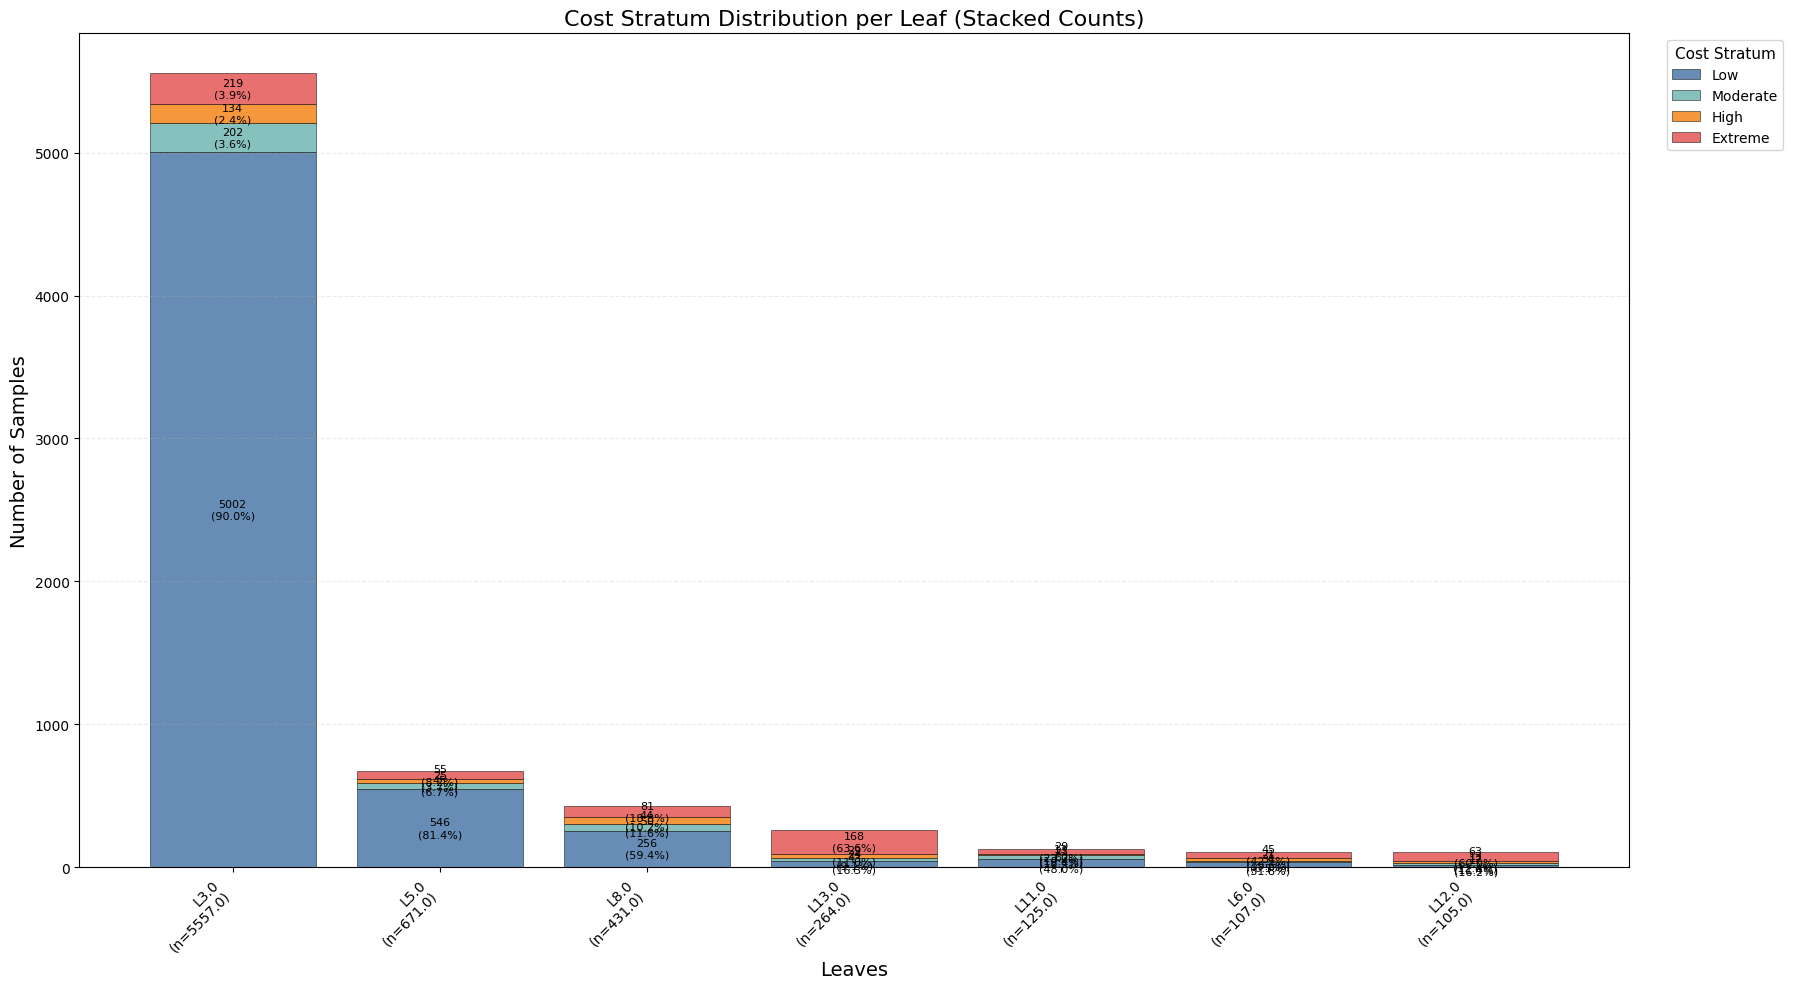


LEAF STRATUM SUMMARY
Overall class distribution across all leaves:
  Stratum 0 (Low): 5958 (82.1%)
  Stratum 1 (Moderate): 363 (5.0%)
  Stratum 2 (High): 279 (3.8%)
  Stratum 3 (Extreme): 660 (9.1%)

Dominant stratum frequency among selected leaves:
  Stratum 0 (Low): 4 leaves (57.1%)
  Stratum 3 (Extreme): 3 leaves (42.9%)

Mean predicted vs actual rates (overall):
 Stratum    Label  Actual_Rate  Pred_Rate
       0      Low        0.821      0.934
       1 Moderate        0.050      0.000
       2     High        0.038      0.000
       3  Extreme        0.091      0.066


In [14]:
import oct_leaf_analysis
importlib.reload(oct_leaf_analysis)
labels = {0: 'Low', 1: 'Moderate', 2: 'High', 3: 'Extreme'}
labels1 = {0: 'Low', 1: 'Moderate', 2: 'High', 3: '200k-300k',4:'>300k'}
labels2 = {0: 'Very Low', 1: 'Low', 2: 'Mild', 3: 'Moderate',4:'High',5: 'Extreme'}
colors = {0: '#4C78A8', 1: '#72B7B2', 2: '#F58518', 3: '#E45756'}
colors2 = {
    0: '#4C78A8',      # blue
    1: '#72B7B2',      # teal
    2: '#A05195',      # purple
    3: '#FFDD44',      # yellow
    4: '#F58518',      # orange
    5: '#E45756'       # red
}
leaf_stats_df = oct_leaf_analysis.visualize_leaf_cost_distributions_4class(
    df_M1, 
    strata = (0, 1, 2, 3),
    strata_labels=labels,
    strata_colors=colors
)



# In-Leaf Undersampling

### Compare optimal vs heuristic

In [9]:
import balancing_functions.optimal_match_lexicographic
importlib.reload(balancing_functions.optimal_match_lexicographic)
from balancing_functions.optimal_match_lexicographic import LexicographicCaseControlResampler
import plotly.express as px
from scipy.spatial.distance import cdist

import time

def compare_vs_optimal_across_k(
    matcher,
    df_cases,
    df_controls,
    exclude_cols_matching,
    target_controls,
    target_cases,
    topk_values=range(10),
    max_controls_per_case=1,
    verbose=True
):
    """
    Compare lexicographic matching vs. full optimal matching across top_k_factor values.
    Measures how many control samples overlap with the full optimization baseline.
    """

    # === 1. Run full optimal (disable lexicographic shortcut)
    if verbose: print("Running baseline: full optimal (disable_lexicographic=True)")
    t0 = time.time()
    full_result = matcher.ortools_optimization_matching(
        dfA=df_cases,
        dfB=df_controls,
        target_controls=target_controls,
        target_cases=target_cases,
        exclude_cols_matching=exclude_cols_matching,
        verbose=True,
        max_controls_per_case=max_controls_per_case,
        disable_lexicographic=True,
    )
    baseline_time = time.time() - t0

    case_ids = set(df_cases["ENROLID"])
    full_control_ids = set(full_result.loc[~full_result["ENROLID"].isin(case_ids), "ENROLID"])
    if verbose:
        print(f"Baseline selected {len(full_control_ids)} controls in {baseline_time:.1f}s\n")

    # === 2. Run lexicographic versions for each k
    results = []
    for k in topk_values:
        t1 = time.time()
        lex_result = matcher.ortools_optimization_matching(
            dfA=df_cases,
            dfB=df_controls,
            target_controls=target_controls,
            target_cases=target_cases,
            exclude_cols_matching=exclude_cols_matching,
            verbose=True,
            max_controls_per_case=max_controls_per_case,
            disable_lexicographic=False,
            inverse_matching=False,
            top_k_factor=k
        )
        lex_time = time.time() - t1

        lex_control_ids = set(lex_result.loc[~lex_result["ENROLID"].isin(case_ids), "ENROLID"])
        intersection = full_control_ids & lex_control_ids

        recall = len(intersection) / len(full_control_ids) if full_control_ids else 0
        precision = len(intersection) / len(lex_control_ids) if lex_control_ids else 0
        jaccard = len(intersection) / len(full_control_ids | lex_control_ids) if full_control_ids else 0

        results.append({
            "top_k_factor": k,
            "shared_controls": len(intersection),
            "n_full_controls": len(full_control_ids),
            "n_lex_controls": len(lex_control_ids),
            "recall_vs_optimal": recall,
            "precision_vs_optimal": precision,
            "common controls/all selected controls": jaccard,
            "lex_time_sec": lex_time,
            "baseline_time_sec": baseline_time
        })

        if verbose:
            print(f"k={k}: overlap={len(intersection)}, recall={recall:.3f}, precision={precision:.3f}, time={lex_time:.1f}s")

    results_df = pd.DataFrame(results)

    # === 3. Plot stability vs. top_k_factor
    fig = px.line(
        results_df,
        x="top_k_factor",
        y=["common controls/all selected controls"],
        markers=True,
        title="Overlap Between Lexicographic Matching and Full Optimal vs. top_k_factor",
        labels={"value": "Overlap metric", "top_k_factor": "Top-k factor"},
    )
    fig.update_traces(mode="lines+markers")
    fig.update_layout(width=700, height=450)
    fig.show()

    return results_df


# === Example usage inside your leaf loop ===
unique_leaves = df_M1['leaf_assignment'].unique()
matcher = LexicographicCaseControlResampler(
        matching_method="ortools",
        random_state=42,
        binary_group="highcost_gt_200000",
        uid_col="ENROLID"
    )
for leaf_id in unique_leaves:
    leaf_df = df_M1[df_M1["leaf_assignment"] == leaf_id]
    majority_df = leaf_df[leaf_df["highcost_gt_200000"] == 0]
    minority_df = leaf_df[leaf_df["highcost_gt_200000"] == 1]

    
    if len(majority_df)> len(minority_df):
        results_df = compare_vs_optimal_across_k(
            matcher=matcher,
            df_cases=minority_df,
            df_controls=majority_df,
            exclude_cols_matching=['leaf_assignment', 'cost_stratum'] + COST_COLUMNS,
            target_controls=len(minority_df),
            target_cases=len(minority_df),
            topk_values=range(7,10),
            verbose=True
        )


NameError: name 'df_M1' is not defined

In [15]:
import balancing_functions.optimal_match_lexicographic
importlib.reload(balancing_functions.optimal_match_lexicographic)
from balancing_functions.optimal_match_lexicographic import LexicographicCaseControlResampler
def create_lexicographic_undersampled_data(pipeline_results, target_col='high_cost_2018', 
                                         undersampling_ratio=1.0, 
                                         balance_tolerance=0.90, max_controls_per_case = 1,
                                         top_k_factor = 10,
                                         verbose=True):
    """
    Parameters:
    
    """
    
    # Extract data from pipeline results
    df_with_leaves = pipeline_results['df_with_leaves']
    feature_cols = pipeline_results['stratification_cols']
    
    # Initialize lexicographic matcher
    matcher = LexicographicCaseControlResampler(
        matching_method="ortools",
        random_state=42,
        binary_group=target_col,
        uid_col="ENROLID"  
    )
    
    print(f"=== LEXICOGRAPHIC OPTIMIZATION UNDERSAMPLING ===")
    print(f"Original dataset: {len(df_with_leaves):,} samples")
    
    # Process each leaf
    unique_leaves = df_with_leaves['leaf_assignment'].unique()
    print(f"Processing {len(unique_leaves)} OCT leaves...")
    
    undersampled_parts = []
    
    for leaf_id in sorted(unique_leaves):
        leaf_df = df_with_leaves[
            df_with_leaves['leaf_assignment'] == leaf_id
        ].copy()

        # Check class distribution
        class_counts = leaf_df[target_col].value_counts()
        if len(class_counts) < 2:
            if verbose:
                print(f"Leaf {leaf_id}: Skipped (single class)")
            continue
            
        majority_class = 0
        minority_class = 1
        n_majority = class_counts[majority_class]
        n_minority = class_counts[minority_class]
                # --- 1. Already balanced? skip undersampling entirely
        imbalance = n_majority - n_minority
        balance_threshold = balance_tolerance * n_minority
        if imbalance <= balance_threshold:
            if verbose:
                print(f"Leaf {leaf_id}: Already balanced "
                    f"(n_maj - n_min: {imbalance} ≤ {balance_tolerance:.1f}×n_min), keeping as-is")
                print(f"  Counts: {n_majority} majority, {n_minority} minority")
                print("")
            undersampled_parts.append(leaf_df)
            continue

        # --- 2. Determine effective ratio (new heuristic)
        desired_ratio = undersampling_ratio   # e.g., 2
        if n_majority < (desired_ratio + 0.3) * n_minority:
            effective_ratio = 1
            if verbose:
                print(f"Leaf {leaf_id}: insufficient controls ({n_majority} vs {n_minority}); "
                    f"falling back to 1:1 matching.")
        else:
            effective_ratio = desired_ratio

        # --- 3. Calculate feasible targets
        target_majority = int(n_minority * effective_ratio)
        max_controls_per_case = effective_ratio

        if n_majority <= 500:
            disable_lexicographic = True ## TODO: changed cutoff to super high to have optimization everywhere!!
        else:
            disable_lexicographic = False

        # Separate classes
        majority_df = leaf_df[leaf_df[target_col] == majority_class].copy()
        minority_df = leaf_df[leaf_df[target_col] == minority_class].copy()
        
        if verbose:
            print(f"\nLeaf {leaf_id}: {n_majority} majority → {target_majority} (keeping {n_minority} minority)")
        
        try:
            matched_df,match_map, match_idx = matcher.ortools_optimization_matching(
                dfA=minority_df,
                dfB=majority_df,
                target_controls=target_majority, 
                target_cases=n_minority,
                exclude_cols_matching=['leaf_assignment', 'cost_stratum']+COST_COLUMNS,
                verbose=verbose,
                max_controls_per_case=max_controls_per_case, 
                top_k_factor=top_k_factor,
                #similarity_threshold=0.7,
                disable_lexicographic=disable_lexicographic,inverse_matching= False
            )
            matched_df["matched_case_uid"] = None
            for ctrl_uid, case_uid in match_map.items():
                matched_df.loc[matched_df["ENROLID"] == ctrl_uid, "matched_case_uid"] = case_uid

            
            undersampled_parts.append(matched_df)
            
            if verbose:
                final_counts = matched_df[target_col].value_counts()
                print(f"  Result: {dict(final_counts)}")
                
        except Exception as e:
            if verbose:
                print(f"  Optimization failed: {e}")
                print(f"  Keeping leaf as-is due to optimization failure")
            undersampled_parts.append(leaf_df)  # Fallback to original
    
    # Combine results
    if undersampled_parts:
        final_result = pd.concat(undersampled_parts, ignore_index=True)
        
        print(f"\n=== FINAL RESULTS ===")
        print(f"Original: {len(df_with_leaves):,} samples")
        print(f"Undersampled: {len(final_result):,} samples")
        print(f"Reduction: {(1-len(final_result)/len(df_with_leaves))*100:.1f}%")
        
        original_dist = df_with_leaves[target_col].value_counts()
        final_dist = final_result[target_col].value_counts()
        print(f"Class distribution:")
        for cls in original_dist.index:
            print(f"  Class {cls}: {original_dist[cls]:,} → {final_dist.get(cls, 0):,}")
        
        return final_result
    else:
        print("Warning: No leaves processed successfully")
        return pd.DataFrame()


for ratio in range(2,3):
    print(" ================================================================== ")

    print("Starting ratio ", ratio)
    print(" ")
    undersampled_training_data = create_lexicographic_undersampled_data(
        pipeline_results=pipeline_results,
        target_col=target_col,
        undersampling_ratio=ratio, max_controls_per_case = ratio, # TODO change to 2,3,4,5
        top_k_factor = 20*ratio,
        verbose=True
    )
    print(f"Final training data size: {len(undersampled_training_data):,}")
    undersampled_training_data.to_csv(f"experiments_1016/prebalanced_matched_ratio_{ratio}_with_ID.csv", index=False)

Starting ratio  2
 
=== LEXICOGRAPHIC OPTIMIZATION UNDERSAMPLING ===
Original dataset: 7,260 samples
Processing 7 OCT leaves...

Leaf 3: 5338 majority → 438 (keeping 219 minority)
>>> Distance computation will use 44 features
5 Categorical features (one-hot encoded): ['INCOME_LEVEL', 'AGEGRP', 'SEX', 'REGION', 'lab_monitoring_intensity']
14 Numeric features (normalized): ['stage_2017', 'util_2017', '2017Q1_ckd_claims', '2017Q1_max_ckd_stage', '2017Q2_ckd_claims', '2017Q2_max_ckd_stage', '2017Q3_ckd_claims', '2017Q3_max_ckd_stage', '2017Q4_ckd_claims', '2017Q4_max_ckd_stage', 'total_lab_tests', 'nephrology_visit_count', 'cost_stratum_2018', 'predicted_cost_stratum']
25 Binary features (unchanged): ['has_Hypertension', 'has_Type_2_Diabetes', 'has_Anemia', 'has_Hyperlipidemia', 'has_Acute_Kidney_Failure', 'has_Hyperparathyroidism', 'has_Kidney_Transplant', 'has_Vitamin_D_Deficiency', 'has_Long-term_Drug_Therapy', 'has_Hypothyroidism', 'has_Sleep_Apnea', 'Antihyperlipidemic Drugs, NEC (THR

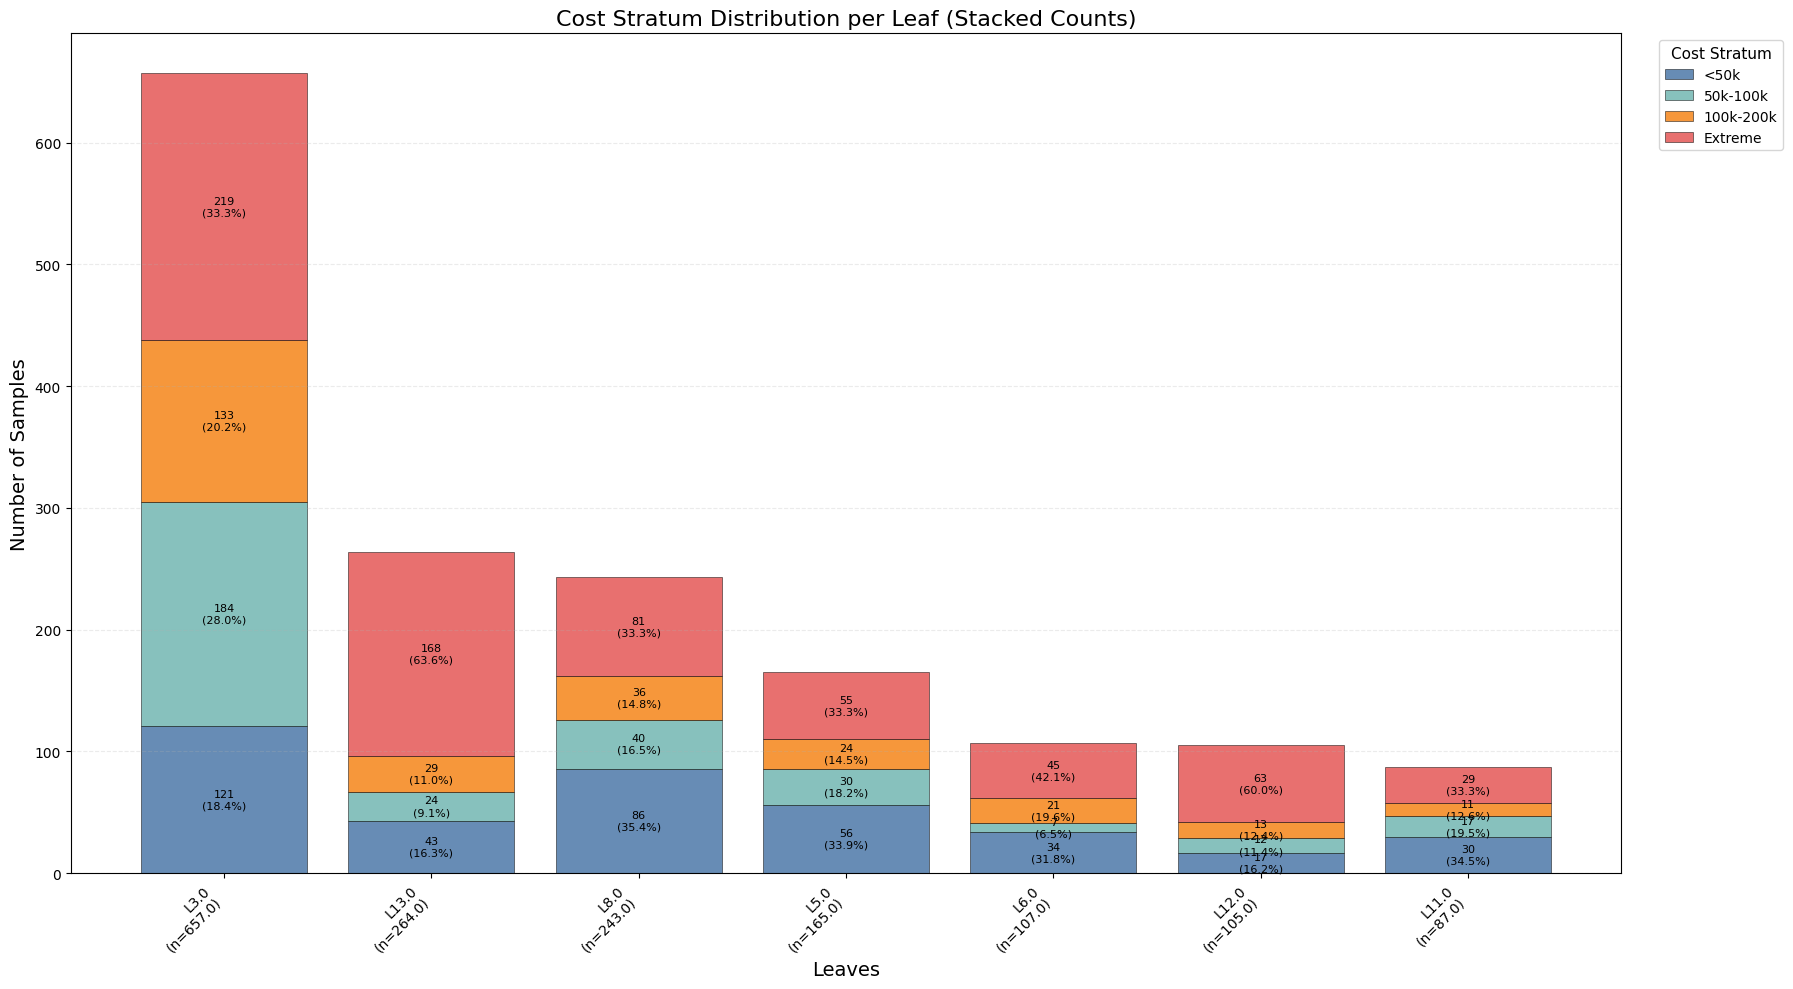


LEAF STRATUM SUMMARY
Overall class distribution across all leaves:
  Stratum 0 (<50k): 387 (23.8%)
  Stratum 1 (50k-100k): 314 (19.3%)
  Stratum 2 (100k-200k): 267 (16.4%)
  Stratum 3 (Extreme): 660 (40.5%)

Dominant stratum frequency among selected leaves:
  Stratum 3 (Extreme): 4 leaves (57.1%)
  Stratum 0 (<50k): 3 leaves (42.9%)

Mean predicted vs actual rates (overall):
 Stratum     Label  Actual_Rate  Pred_Rate
       0      <50k        0.238      0.708
       1  50k-100k        0.193      0.000
       2 100k-200k        0.164      0.000
       3   Extreme        0.405      0.292


In [16]:
labels = {0: 'Low', 1: 'Moderate', 2: 'High', 3: 'Extreme'}
labels = {0: '<50k', 1: '50k-100k', 2: '100k-200k', 3: 'Extreme'}
colors = {0: '#4C78A8', 1: '#72B7B2', 2: '#F58518', 3: '#E45756'}
leaf_stats_df = oct_leaf_analysis.visualize_leaf_cost_distributions_4class(
    undersampled_training_data,
     strata = (0, 1, 2, 3),
    strata_labels=labels,
    strata_colors=colors

)


# Inspect differences in patients using different sampling methods

In [ ]:
from typing import Any


matched_1 =  pd.read_csv(f"experiments_1016/prebalanced_matched_ratio_2_with_ID.csv")
matched_assignments = pd.read_csv("inner_assignment_solution_with_uids.csv")
matched_2 = pd.read_csv("inner_candidate_ctrls_K13200.csv")   # should contain ENROLID or UID
bilevel = pd.read_csv("undersampled_bilevel_K{K}.csv")   # should contain ENROLID or UID
print(matched_1.shape, matched_2.shape)


(1244, 98) (13200, 2)


In [18]:
len(matched_2['control_uid'].unique())

# Check 1: Which enrolid in matched_1 is in matched_2 control_uid
overlap_final= matched_1[matched_1['ENROLID'].isin(bilevel['ENROLID'])]
print(f"Number of ENROLID in matched_1 that are in matched_2 control_uid: {len(overlap_final)}")
overlap_final["highcost_gt_200000"].value_counts()

Number of ENROLID in matched_1 that are in matched_2 control_uid: 501


highcost_gt_200000
1    464
0     37
Name: count, dtype: int64

In [14]:

# Check 1: Which enrolid in matched_1 is in matched_2 control_uid
enrolid_in_control_uid = matched_1[matched_1['ENROLID'].isin(matched_2['control_uid'])]
print(f"Number of ENROLID in matched_1 that are in matched_2 control_uid: {len(enrolid_in_control_uid)}")
enrolid_in_control_uid = matched_1[matched_1['ENROLID'].isin(matched_assignments['control_uid'])]
print(f"Number of ENROLID in matched_1 that are in matched_assignments control_uid: {len(enrolid_in_control_uid)}")


Number of ENROLID in matched_1 that are in matched_2 control_uid: 256
Number of ENROLID in matched_1 that are in matched_assignments control_uid: 45


In [ ]:
import numpy as np
from scipy.stats import ttest_ind, mannwhitneyu

def feature_summary(df1, df2):
    stats = []
    for col in df1.columns:
        if pd.api.types.is_numeric_dtype(df1[col]):
            mean1 = df1[col].mean()
            mean2 = df2[col].mean()
            std1 = df1[col].std()
            std2 = df2[col].std()
            # t-test (parametric) and Mann-Whitney U (nonparametric)
            ttest_p = ttest_ind(df1[col].dropna(), df2[col].dropna(), equal_var=False).pvalue
            mw_p = mannwhitneyu(df1[col].dropna(), df2[col].dropna(), alternative='two-sided').pvalue
            stats.append({
                'feature': col,
                'mean_setdiff1': mean1,
                'mean_setdiff2': mean2,
                'std_setdiff1': std1,
                'std_setdiff2': std2,
                'ttest_p': ttest_p,
                'mannwhitneyu_p': mw_p
            })
        else:
            # For categorical: compare value counts/frequencies
            freq1 = df1[col].value_counts(normalize=True)
            freq2 = df2[col].value_counts(normalize=True)
            stats.append({
                'feature': col,
                'freq_setdiff1': freq1.to_dict(),
                'freq_setdiff2': freq2.to_dict()
            })
    return pd.DataFrame(stats)
#pd.set_option('display.max_columns', None)   # Show all columns
pd.set_option('display.max_rows', None)   # Show all columns
pd.set_option('display.max_colwidth', None)  # Show full content of each cell
pd.set_option('display.width', None)         # Don't wrap lines

summary_df = feature_summary(unique_1[feature_cols], unique_2[feature_cols])
summary_df.sort_values('ttest_p', inplace=True)  # Optional: sort by significance
summary_df
## freq_setdiff1: value frequencies in rows unique to set 1 after matching (undersampled_training_data)

In [27]:
pd.reset_option('display.max_columns')
pd.reset_option('display.width')
pd.reset_option('display.max_colwidth')
pd.reset_option('display.max_rows')

# Evaluate Final Prediction Models

## Model M2

In [54]:
import model_IAI
importlib.reload(model_IAI)
from model_IAI import train_and_evaluate_for_w
for ratio in range(1,2):
    print(" ================================================================== ")

    print("Starting ratio ", ratio)
    print(" ")
    undersampled_training_data = pd.read_csv(f"experiments_1016/prebalanced_matched_ratio_{ratio}.csv")
    output = train_and_evaluate_for_w(undersampled_training_data,X_test,y_test,feature_cols,
    categorical_cols=CAT_COLUMNS,numeric_cols=TRUE_NUM_COLUMNS)
    pd.DataFrame([output]).to_csv(f"ratio{ratio}_results.csv", index=False)


Starting ratio  1
 
Training: 870, Validation: 374
→ Building preprocessor:
   • OneHotEncoder on: ['INCOME_LEVEL', 'AGEGRP', 'SEX', 'REGION', 'cost_pattern_2017', 'cost_stability_2017', 'lab_monitoring_intensity']
   • StandardScaler on: ['2017Q1_ckd_cost', '2017Q1_ckd_claims', '2017Q1_direct_ckd_cost', '2017Q1_procedure_ckd_cost', '2017Q1_comorbidity_ckd_cost', '2017Q2_ckd_cost', '2017Q2_ckd_claims', '2017Q2_direct_ckd_cost', '2017Q2_procedure_ckd_cost', '2017Q2_comorbidity_ckd_cost', '2017Q3_ckd_cost', '2017Q3_ckd_claims', '2017Q3_direct_ckd_cost', '2017Q3_procedure_ckd_cost', '2017Q3_comorbidity_ckd_cost', '2017Q4_ckd_cost', '2017Q4_ckd_claims', '2017Q4_direct_ckd_cost', '2017Q4_procedure_ckd_cost', '2017Q4_comorbidity_ckd_cost', 'ckd_cost_trend_2017', 'ckd_cost_volatility_2017', 'ckd_cost_deriv_Q1_Q2_2017', 'ckd_cost_deriv_Q2_Q3_2017', 'ckd_cost_deriv_Q3_Q4_2017', 'avg_quarterly_derivative_2017', 'quarterly_std_2017', 'quarterly_skewness_2017', 'quarterly_kurtosis_2017', 'quarterl

/Users/cat2510/.pyenv/versions/3.11.0/envs/analytics/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


✓ Cost stratum test predictions completed


[ Warning: The type of y (Any) does not match the original target type (Int64)
[ Warning: The type of y (Any) does not match the original target type (Int64)


AUC score: 0.685
Misclassification score: 0.675
Sensitivity (Recall): 0.611
Specificity: 0.677
Confusion Matrix:
 [[6617 3163]
 [ 110  173]]


[ Warning: The type of y (Any) does not match the original target type (Int64)


In [8]:
import model_IAI
importlib.reload(model_IAI)
from model_IAI import finetune_oct, evaluate_binary_oct
minbuckets_M2=[50,100,120]
cps_M2=[0.00001,5e-4, 0.0001,5e-3, 0.001, 0.01, 0.1]
depths_M2=[5,7,9]

In [ ]:
_,_,undersampled_train,undersampled_val = model_pipeline.train_test_split_enrol(
    undersampled_training_data, target_col = target_col,test_size=0.2,verbose=False)
X_train_undersampled = undersampled_train[feature_cols]
y_train_undersampled = undersampled_train[target_col]
print(X_train_undersampled.shape)

balanced_model, balanced_params, results_balanced,preprocessor, feature_names = finetune_oct(
    X_train_undersampled, y_train_undersampled,X_val, y_val,categorical_cols=CAT_COLUMNS, numeric_cols=TRUE_NUM_COLUMNS,
    depths=depths_M2,
    minbuckets=minbuckets_M2,
    cps=cps_M2
)

print("Best params:", balanced_params)
print(results_balanced)
evaluate_binary_oct(balanced_model,X_test,y_test,preprocessor,feature_names)



(1900, 78)
→ Building preprocessor:
   • OneHotEncoder on: ['INCOME_LEVEL', 'AGEGRP', 'SEX', 'REGION', 'cost_pattern_2017', 'cost_stability_2017', 'lab_monitoring_intensity']
   • StandardScaler on: ['2017Q1_ckd_cost', '2017Q1_ckd_claims', '2017Q1_direct_ckd_cost', '2017Q1_procedure_ckd_cost', '2017Q1_comorbidity_ckd_cost', '2017Q2_ckd_cost', '2017Q2_ckd_claims', '2017Q2_direct_ckd_cost', '2017Q2_procedure_ckd_cost', '2017Q2_comorbidity_ckd_cost', '2017Q3_ckd_cost', '2017Q3_ckd_claims', '2017Q3_direct_ckd_cost', '2017Q3_procedure_ckd_cost', '2017Q3_comorbidity_ckd_cost', '2017Q4_ckd_cost', '2017Q4_ckd_claims', '2017Q4_direct_ckd_cost', '2017Q4_procedure_ckd_cost', '2017Q4_comorbidity_ckd_cost', 'ckd_cost_trend_2017', 'ckd_cost_volatility_2017', 'ckd_cost_deriv_Q1_Q2_2017', 'ckd_cost_deriv_Q2_Q3_2017', 'ckd_cost_deriv_Q3_Q4_2017', 'avg_quarterly_derivative_2017', 'quarterly_std_2017', 'quarterly_skewness_2017', 'quarterly_kurtosis_2017', 'quarterly_cv_2017', 'quarterly_max_2017', 'quart

Fitted OptimalTreeClassifier:
  1) Split: 2017Q4_ckd_cost < 0.187
    2) Split: Analg/Antipyr, Opiate Agonists (THRCLS_60) < 0.5
      3) Predict: 0 (90.18%), [542,59], 601 points, error 0.09817
      4) Split: 2017Q3_max_ckd_stage < 3.5
        5) Split: ckd_cost_deriv_Q2_Q3_2017 < -0.05361
          6) Split: Cardiac, Calcium Channel (THRCLS_52) < 0.5
            7) Predict: 0 (85.96%), [202,33], 235 points, error 0.1404
            8) Split: stage_2017 < 3.5
              9) Predict: 0 (77.94%), [212,60], 272 points, error 0.2206
              10) Predict: 1 (60.78%), [20,31], 51 points, error 0.3922
          11) Predict: 0 (78.26%), [144,40], 184 points, error 0.2174
        12) Split: 2017Q4_direct_ckd_cost < -0.2286
          13) Predict: 0 (71.32%), [92,37], 129 points, error 0.2868
          14) Split: 2017Q3_direct_ckd_cost < -0.1788
            15) Predict: 1 (69.64%), [17,39], 56 points, error 0.3036
            16) Predict: 0 (67.24%), [39,19], 58 points, error 0.3276
    17) Split: stage_2017 < 3.5
      18) Split: quarterly_max_2017 < 0.5303
        19) Predict: 0 (69.35%), [43,19], 62 points, error 0.3065
        20) Predict: 1 (75.00%), [21,63], 84 points, error 0.25
      21) Predict: 1 (76.19%), [40,128], 168 points, error 0.2381

In [20]:
from imblearn.under_sampling import RandomUnderSampler
target_col = 'highcost_gt_200000'
X = train_pd.drop(columns=[target_col])
y = train_pd[target_col]

rus = RandomUnderSampler(random_state=42)
X_res, y_res = rus.fit_resample(X, y)

undersampled_rus = pd.concat([X_res, y_res], axis=1)
print(undersampled_rus['cost_stratum_2018'].value_counts())

print(X_res.shape)
rus_model, rus_params, results_rus,preprocessor, feature_names = finetune_oct(
    X_res[feature_cols], y_res,X_val, y_val,categorical_cols=CAT_COLUMNS, numeric_cols=TRUE_NUM_COLUMNS,
    depths=depths_M2,
    minbuckets=minbuckets_M2,
    cps=cps_M2
)

print("Best params:", rus_params)
print(results_rus)
rus_model


evaluate_binary_oct(rus_model,X_test,y_test,preprocessor,feature_names)

cost_stratum_2018
3    660
0    603
1     32
2     25
Name: count, dtype: int64
(1320, 95)
→ Building preprocessor:
   • OneHotEncoder on: ['INCOME_LEVEL', 'AGEGRP', 'SEX', 'REGION', 'cost_pattern_2017', 'cost_stability_2017', 'lab_monitoring_intensity']
   • StandardScaler on: ['2017Q1_ckd_cost', '2017Q1_ckd_claims', '2017Q1_direct_ckd_cost', '2017Q1_procedure_ckd_cost', '2017Q1_comorbidity_ckd_cost', '2017Q2_ckd_cost', '2017Q2_ckd_claims', '2017Q2_direct_ckd_cost', '2017Q2_procedure_ckd_cost', '2017Q2_comorbidity_ckd_cost', '2017Q3_ckd_cost', '2017Q3_ckd_claims', '2017Q3_direct_ckd_cost', '2017Q3_procedure_ckd_cost', '2017Q3_comorbidity_ckd_cost', '2017Q4_ckd_cost', '2017Q4_ckd_claims', '2017Q4_direct_ckd_cost', '2017Q4_procedure_ckd_cost', '2017Q4_comorbidity_ckd_cost', 'ckd_cost_trend_2017', 'ckd_cost_volatility_2017', 'ckd_cost_deriv_Q1_Q2_2017', 'ckd_cost_deriv_Q2_Q3_2017', 'ckd_cost_deriv_Q3_Q4_2017', 'avg_quarterly_derivative_2017', 'quarterly_std_2017', 'quarterly_skewness_201

Test dataset for OCT application: 10,063 samples
✓ Feature names: ['INCOME_LEVEL_1', 'INCOME_LEVEL_2', 'INCOME_LEVEL_3', 'AGEGRP_2', 'AGEGRP_3', 'AGEGRP_4', 'AGEGRP_5', 'SEX_2', 'REGION_2', 'REGION_3', 'REGION_4', 'REGION_5', 'cost_pattern_2017_early_heavy', 'cost_pattern_2017_late_heavy', 'cost_stability_2017_moderate', 'cost_stability_2017_stable', 'lab_monitoring_intensity_Low', 'lab_monitoring_intensity_Minimal', 'lab_monitoring_intensity_Moderate', '2017Q1_ckd_cost', '2017Q1_ckd_claims', '2017Q1_direct_ckd_cost', '2017Q1_procedure_ckd_cost', '2017Q1_comorbidity_ckd_cost', '2017Q2_ckd_cost', '2017Q2_ckd_claims', '2017Q2_direct_ckd_cost', '2017Q2_procedure_ckd_cost', '2017Q2_comorbidity_ckd_cost', '2017Q3_ckd_cost', '2017Q3_ckd_claims', '2017Q3_direct_ckd_cost', '2017Q3_procedure_ckd_cost', '2017Q3_comorbidity_ckd_cost', '2017Q4_ckd_cost', '2017Q4_ckd_claims', '2017Q4_direct_ckd_cost', '2017Q4_procedure_ckd_cost', '2017Q4_comorbidity_ckd_cost', 'ckd_cost_trend_2017', 'ckd_cost_volat

In [ ]:
matched_1 =  pd.read_csv(f"experiments_1016/prebalanced_matched_ratio_2.csv")
matched_2 = pd.read_csv("inner_assignment_solution_with_uids.csv")
print(matched_2.shape, matched_1.shape)



In [ ]:
# Check 1: Which enrolid in matched_1 is in matched_2 control_uid
enrolid_in_control_uid = matched_1[matched_1['ENROLID'].isin(matched_2['control_uid'])]
print(f"Number of ENROLID in matched_1 that are in matched_2 control_uid: {len(enrolid_in_control_uid)}")
print(f"\nUnique ENROLIDs in matched_1 that are in matched_2 control_uid:")
print(enrolid_in_control_uid['ENROLID'].unique())
print(f"\nTotal unique count: {enrolid_in_control_uid['ENROLID'].nunique()}")

# Check 2: Verify all case_uid in matched_2 are in matched_1.ENROLID
case_uids_in_matched_1 = matched_2['case_uid'].isin(matched_1['ENROLID'])
all_cases_present = case_uids_in_matched_1.all()
missing_cases = matched_2[~case_uids_in_matched_1]['case_uid'].unique() if not all_cases_present else []

print(f"\n{'='*80}")
print(f"Check 2: All case_uid in matched_2 are in matched_1.ENROLID")
print(f"{'='*80}")
print(f"Total case_uid in matched_2: {matched_2['case_uid'].nunique()}")
print(f"Total case_uid in matched_2 that are in matched_1.ENROLID: {case_uids_in_matched_1.sum()}")
print(f"All case_uid present in matched_1.ENROLID: {all_cases_present}")

if not all_cases_present:
    print(f"\nMissing case_uid (not in matched_1.ENROLID):")
    print(missing_cases)
else:
    print("\n✓ All case_uid in matched_2 are present in matched_1.ENROLID")



,seed,w,auc,recall,specificity,precision,f1,train_size,val_size
0,42,0.0,0.788768,0.593640,0.863395,0.111702,0.188025,1139,489
1,42,0.2,0.813658,0.512367,0.923313,0.162011,0.246180,1201,515
2,42,0.4,0.787955,0.498233,0.893252,0.118987,0.192098,1201,515
3,42,0.6,0.773768,0.491166,0.917587,0.147090,0.226384,1200,515
4,42,0.8,0.754367,0.508834,0.887219,0.115477,0.188235,1169,502
5,42,0.9,0.805158,0.593640,0.870654,0.117237,0.195804,1154,495
6,42,1.0,0.754003,0.597173,0.856544,0.107506,0.182210,1139,489
7,101,0.0,0.796418,0.491166,0.920245,0.151251,0.231281,1139,489
8,101,0.2,0.804322,0.515901,0.887014,0.116707,0.190352,1201,515
9,101,0.4,0.785173,0.477032,0.894479,0.115681,0.186207,1201,515


w       auc                                  recall                      \
            mean       std       min       max      mean       std       min   
0  0.0  0.792292  0.003860  0.788768  0.796418  0.535925  0.052451  0.491166   
1  0.2  0.807205  0.005599  0.803635  0.813658  0.499411  0.025562  0.469965   
2  0.4  0.793948  0.012864  0.785173  0.808715  0.504122  0.030465  0.477032   
3  0.6  0.772906  0.001219  0.772044  0.773768  0.503534  0.017490  0.491166   
4  0.8  0.771675  0.024477  0.754367  0.788983  0.537102  0.039978  0.508834   
5  0.9  0.787326  0.025218  0.769495  0.805158  0.567138  0.037479  0.540636   
6  1.0  0.774769  0.029366  0.754003  0.795534  0.606007  0.012493  0.597173   

            specificity                               precision            \
        max        mean       std       min       max      mean       std   
0  0.593640    0.889230  0.028777  0.863395  0.920245  0.126133  0.021834   
1  0.515901    0.913088  0.022755  0.887014  0.928937  0.146449  0.025767   
2  0.537102    0.889502  0.007581  0.880777  0.894479  0.116665  0.002019   
3  0.515901    0.884918  0.046201  0.852249  0.917587  0.119428  0.039120   
4  0.565371    0.871830  0.021763  0.856442  0.887219  0.108889  0.009316   
5  0.593640    0.852812  0.025233  0.834969  0.870654  0.101912  0.021672   
6  0.614841    0.859100  0.003615  0.856544  0.861656  0.110728  0.004556   

                       
        min       max  
0  0.111702  0.151251  
1  0.116707  0.162011  
2  0.115326  0.118987  
3  0.091766  0.147090  
4  0.102302  0.115477  
5  0.086587  0.117237  
6  0.107506  0.113949

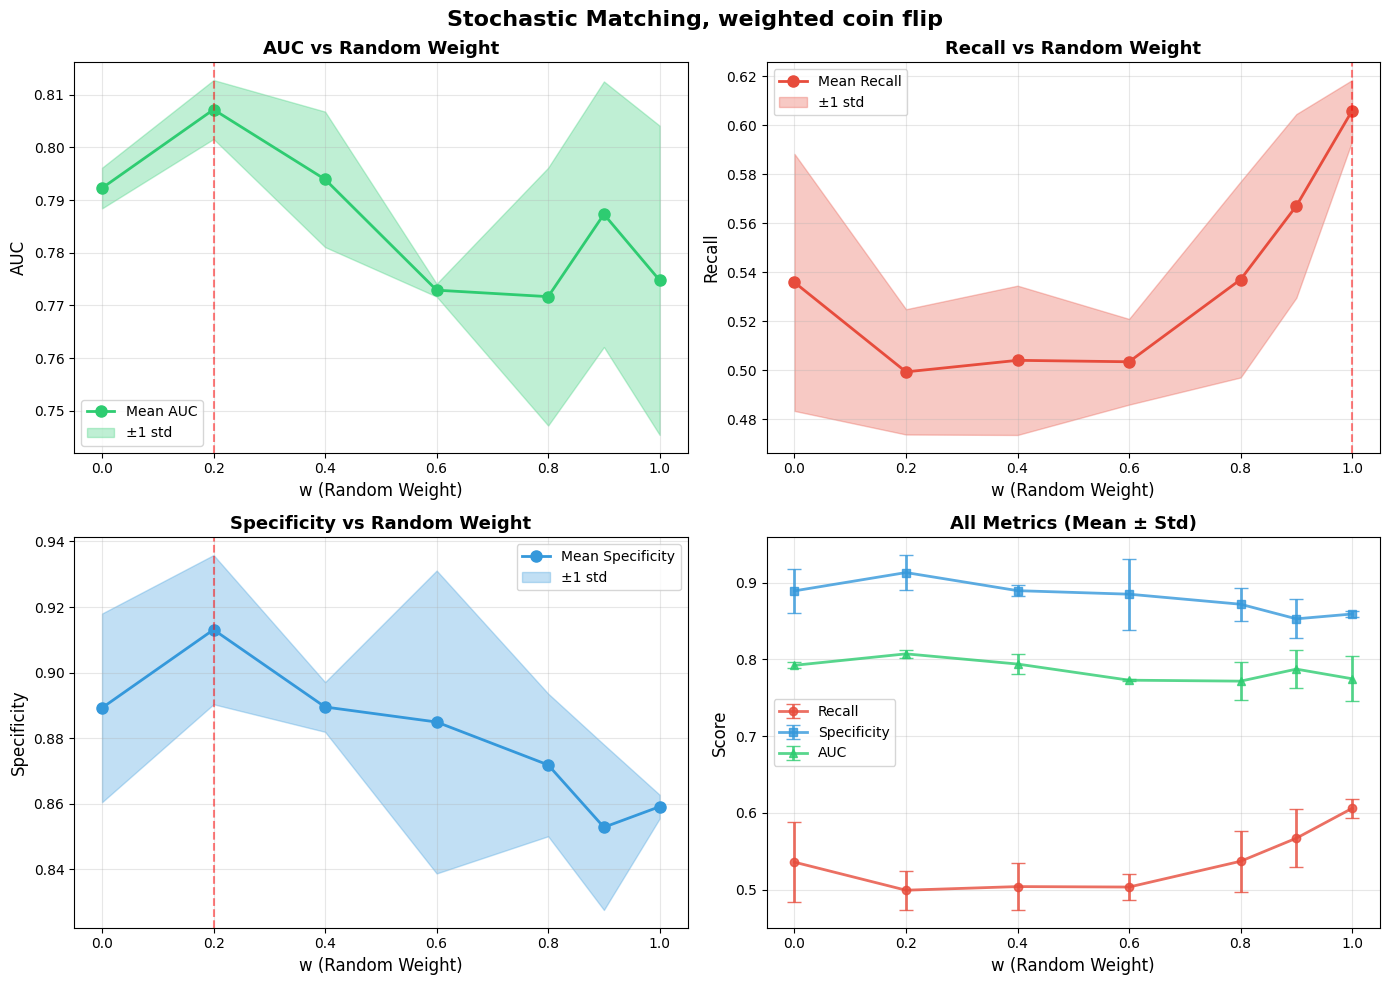


SUMMARY: Mean ± Std across runs
w      AUC                  Recall               Specificity         
--------------------------------------------------------------------------------
0.00   0.7923±0.0039  0.5359±0.0525  0.8892±0.0288
0.20   0.8072±0.0056  0.4994±0.0256  0.9131±0.0228
0.40   0.7939±0.0129  0.5041±0.0305  0.8895±0.0076
0.60   0.7729±0.0012  0.5035±0.0175  0.8849±0.0462
0.80   0.7717±0.0245  0.5371±0.0400  0.8718±0.0218
0.90   0.7873±0.0252  0.5671±0.0375  0.8528±0.0252
1.00   0.7748±0.0294  0.6060±0.0125  0.8591±0.0036


In [25]:

# ============================================================================
# Plotting with confidence intervals
# ============================================================================
results_df = pd.read_csv("./experiments_1016/results_prebalance_1to10.csv")
display(results_df)
def plot_results_with_confidence(results_df, title='AUC vs Random Weight',save_path='./w_results_with_ci.png'):
    """
    Plot mean ± std (or confidence intervals) for each metric vs w.
    """
    
    # Calculate statistics per w value
    stats = results_df.groupby('w').agg({
        'auc': ['mean', 'std', 'min', 'max'],
        'recall': ['mean', 'std', 'min', 'max'],
        'specificity': ['mean', 'std', 'min', 'max'],
        'precision': ['mean', 'std', 'min', 'max']
    }).reset_index()
    display(stats)
    # Flatten column names
    stats.columns = ['_'.join(col).strip('_') for col in stats.columns.values]
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(title, 
                 fontsize=16, fontweight='bold')
    
    w_vals = stats['w'].values
    
    # Plot 1: AUC
    ax1 = axes[0, 0]
    ax1.plot(w_vals, stats['auc_mean'], 'o-', linewidth=2, 
             markersize=8, color='#2ecc71', label='Mean AUC')
    ax1.fill_between(w_vals, 
                     stats['auc_mean'] - stats['auc_std'],
                     stats['auc_mean'] + stats['auc_std'],
                     alpha=0.3, color='#2ecc71', label='±1 std')
    ax1.set_xlabel('w (Random Weight)', fontsize=12)
    ax1.set_ylabel('AUC', fontsize=12)
    ax1.set_title("AUC vs Random Weight", fontsize=13, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    # Annotate best
    best_w = stats.loc[stats['auc_mean'].idxmax(), 'w']
    ax1.axvline(best_w, color='red', linestyle='--', alpha=0.5)
    
    # Plot 2: Recall
    ax2 = axes[0, 1]
    ax2.plot(w_vals, stats['recall_mean'], 'o-', linewidth=2, 
             markersize=8, color='#e74c3c', label='Mean Recall')
    ax2.fill_between(w_vals,
                     stats['recall_mean'] - stats['recall_std'],
                     stats['recall_mean'] + stats['recall_std'],
                     alpha=0.3, color='#e74c3c', label='±1 std')
    ax2.set_xlabel('w (Random Weight)', fontsize=12)
    ax2.set_ylabel('Recall', fontsize=12)
    ax2.set_title('Recall vs Random Weight', fontsize=13, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    best_w = stats.loc[stats['recall_mean'].idxmax(), 'w']
    ax2.axvline(best_w, color='red', linestyle='--', alpha=0.5)
    
    # Plot 3: Specificity
    ax3 = axes[1, 0]
    ax3.plot(w_vals, stats['specificity_mean'], 'o-', linewidth=2,
             markersize=8, color='#3498db', label='Mean Specificity')
    ax3.fill_between(w_vals,
                     stats['specificity_mean'] - stats['specificity_std'],
                     stats['specificity_mean'] + stats['specificity_std'],
                     alpha=0.3, color='#3498db', label='±1 std')
    ax3.set_xlabel('w (Random Weight)', fontsize=12)
    ax3.set_ylabel('Specificity', fontsize=12)
    ax3.set_title('Specificity vs Random Weight', fontsize=13, fontweight='bold')
    ax3.grid(True, alpha=0.3)
    ax3.legend()
    
    best_w = stats.loc[stats['specificity_mean'].idxmax(), 'w']
    ax3.axvline(best_w, color='red', linestyle='--', alpha=0.5)
    
    # Plot 4: All metrics with error bars
    ax4 = axes[1, 1]
    ax4.errorbar(w_vals, stats['recall_mean'], yerr=stats['recall_std'],
                 fmt='o-', linewidth=2, markersize=6, color='#e74c3c',
                 label='Recall', capsize=5, alpha=0.8)
    ax4.errorbar(w_vals, stats['specificity_mean'], yerr=stats['specificity_std'],
                 fmt='s-', linewidth=2, markersize=6, color='#3498db',
                 label='Specificity', capsize=5, alpha=0.8)
    ax4.errorbar(w_vals, stats['auc_mean'], yerr=stats['auc_std'],
                 fmt='^-', linewidth=2, markersize=6, color='#2ecc71',
                 label='AUC', capsize=5, alpha=0.8)
    ax4.set_xlabel('w (Random Weight)', fontsize=12)
    ax4.set_ylabel('Score', fontsize=12)
    ax4.set_title('All Metrics (Mean ± Std)', fontsize=13, fontweight='bold')
    ax4.grid(True, alpha=0.3)
    ax4.legend(loc='best')
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print summary table
    print(f"\n{'='*80}")
    print("SUMMARY: Mean ± Std across runs")
    print(f"{'='*80}")
    print(f"{'w':<6} {'AUC':<20} {'Recall':<20} {'Specificity':<20}")
    print("-" * 80)
    
    for _, row in stats.iterrows():
        print(f"{row['w']:<6.2f} "
              f"{row['auc_mean']:.4f}±{row['auc_std']:.4f}  "
              f"{row['recall_mean']:.4f}±{row['recall_std']:.4f}  "
              f"{row['specificity_mean']:.4f}±{row['specificity_std']:.4f}")
    
    return stats

# Plot with confidence intervals
stats = plot_results_with_confidence(
    results_df, title = "Stochastic Matching, weighted coin flip",
    save_path='./w_results_stochastic_matching.png'
)